In [1]:
from config import DEVELOPMENT_SET, INPUT_JSON, OUTPUT_EXAMPLE
from utils import *

### **Loading the image list and the optional ground truth**

Loads the image list from example_json and prints the first 5 image paths. Output example json file contains only 1 example of the desired output for this task.
- ***load_input_paths(input_json)***
- ***load_output_example(output_json)***

In [2]:
image_paths = load_input_paths(input_json=INPUT_JSON)
print("Number of images from input.json:", len(image_paths))
print("First 5:")
for p in image_paths[:5]:
    print(" -", p)

gt_example = None
if OUTPUT_EXAMPLE.exists():
    gt_example = load_output_example(output_json=OUTPUT_EXAMPLE)
    print("\nLoaded output example with", len(gt_example), "records")
else:
    print("\nNo output example found")

Number of images from input.json: 50
First 5:
 - /Users/sarataboas/Desktop/master/2_semester/computer_vision/8_BallPool_ComputerVision/development_set/106_png.rf.28ee53acf89d9e7f17b2fb26185597a0.jpg
 - /Users/sarataboas/Desktop/master/2_semester/computer_vision/8_BallPool_ComputerVision/development_set/10a_png.rf.bdc9984ba169594ea32b012098ad10dd.jpg
 - /Users/sarataboas/Desktop/master/2_semester/computer_vision/8_BallPool_ComputerVision/development_set/110_png.rf.9a38b6057e543f83b58aa59b9748688b.jpg
 - /Users/sarataboas/Desktop/master/2_semester/computer_vision/8_BallPool_ComputerVision/development_set/114_png.rf.98b2144c25b9f48816abd7edb00f365c.jpg
 - /Users/sarataboas/Desktop/master/2_semester/computer_vision/8_BallPool_ComputerVision/development_set/115_png.rf.ed51d53dd5c384b1f26a2b6ece52ad69.jpg

Loaded output example with 1 records


### **Dataset Inspection**

Run this several times on different images. Change `IDX` freely.

In [3]:
IDX = 8

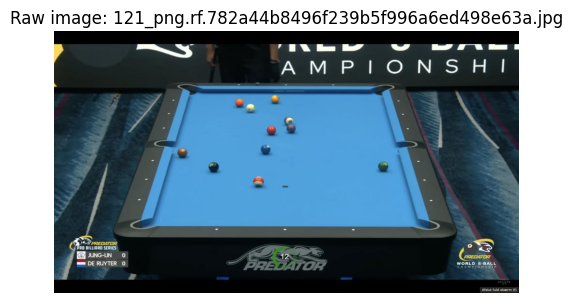

In [4]:
img_path = image_paths[IDX]
img_rgb = imread_rgb(img_path)

show(img_rgb, title=f"Raw image: {img_path.name}", figsize=(6, 4))

### **Color spaces**

This helps decide whether HSV alone is enough, or whether LAB / grayscale also help.

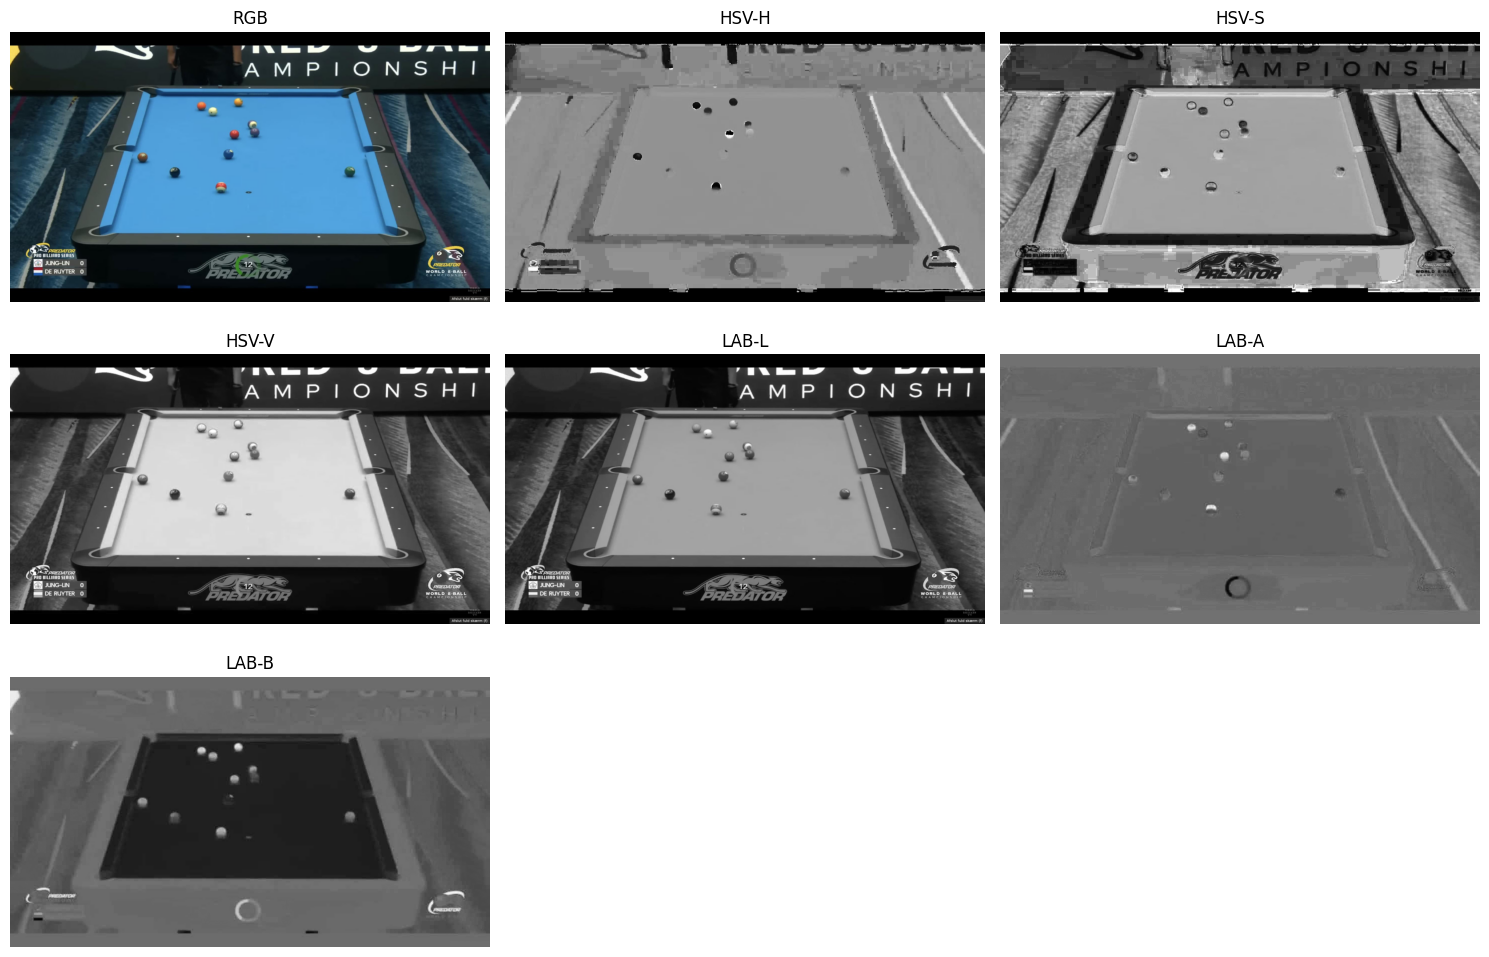

In [5]:
bgr = imread_bgr(img_path)
rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
lab = cv2.cvtColor(bgr, cv2.COLOR_BGR2LAB)

images = [rgb,
          hsv[:, :, 0], hsv[:, :, 1], hsv[:, :, 2],
          lab[:, :, 0], lab[:, :, 1], lab[:, :, 2]]

titles = ["RGB", "HSV-H", "HSV-S", "HSV-V", "LAB-L", "LAB-A", "LAB-B"]
show_many(images, titles=titles, cols=3, figsize=(15, 10))


From the visualization of RGB, HSV, and LAB channels, we can extract the following insights:

- Hue (HSV-H) is relatively uniform for the table but unstable in low-saturation regions (shadows, reflections), making it unreliable as a standalone feature.
- Saturation (HSV-S) clearly separates the table from the background.
The table cloth has consistently high saturation, while surrounding elements (walls, players, text) have lower saturation.

    → This makes HSV-S a strong candidate for table segmentation.


- Value (HSV-V) and LAB-L (lightness) mainly encode brightness and do not provide strong discrimination between table and background.

- LAB-B channel provides a very strong contrast between the table and the balls.
The table appears homogeneous, while the balls stand out clearly as distinct regions.

    → This makes LAB-B particularly useful for ball detection.
    
For ball classification, HSV remains the most appropriate space, since hue directly encodes color information.

## **Table Detection**

**Goal:** *Obtain a reliable top-view transformation*

**Methodology:**

- ***Mask*** — segment the table region from the image
- ***Contour*** — extract the main shape corresponding to the table
- ***Corners*** — estimate the four corner points of that shape
- ***Warp*** — apply a perspective transform to obtain a normalized top-view

### **Mask**

Candidate methods for table detection: 

1. Fixed HSV thresholding (baseline)
2. Saturation-based segmentation
3. Adaptive color estimation from the image

1. **Fixed HSV thresholding**

In [6]:
def detect_table_hsv_basic(bgr, blue_lower=(85, 40, 40), blue_upper=(130, 255, 255), 
                           green_lower=(35, 30, 30), green_upper=(90, 255, 255)):
    
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)

    mask_blue = cv2.inRange(hsv, np.array(blue_lower), np.array(blue_upper))
    mask_green = cv2.inRange(hsv, np.array(green_lower), np.array(green_upper))
    mask = cv2.bitwise_or(mask_blue, mask_green)

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (9, 9))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    return mask


2. **Saturation/value thresholding**

In [7]:
def detect_table_satval(bgr, sat_thr=40, val_thr=40):
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    s = hsv[:, :, 1]
    v = hsv[:, :, 2]

    mask = ((s > sat_thr) & (v > val_thr)).astype(np.uint8) * 255

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    return mask

3. **Saturation/value thresholding**

In [8]:
def detect_table_mask_adaptive(bgr):
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    h, w = hsv.shape[:2]

    cx1, cy1 = int(w * 0.35), int(h * 0.35)
    cx2, cy2 = int(w * 0.65), int(h * 0.65)
    center = hsv[cy1:cy2, cx1:cx2]

    h_vals = center[:, :, 0].reshape(-1)
    s_vals = center[:, :, 1].reshape(-1)
    v_vals = center[:, :, 2].reshape(-1)

    valid = (s_vals > 50) & (v_vals > 50)
    if valid.sum() < 50:
        return None

    h_med = int(np.median(h_vals[valid]))
    low = max(0, h_med - 18)
    high = min(179, h_med + 18)

    mask = cv2.inRange(hsv, np.array([low, 70, 70]), np.array([high, 255, 255]))

    # remove likely noise bands
    mask[:int(0.2 * h), :] = 0
    mask[int(0.9 * h):, :] = 0

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    return mask

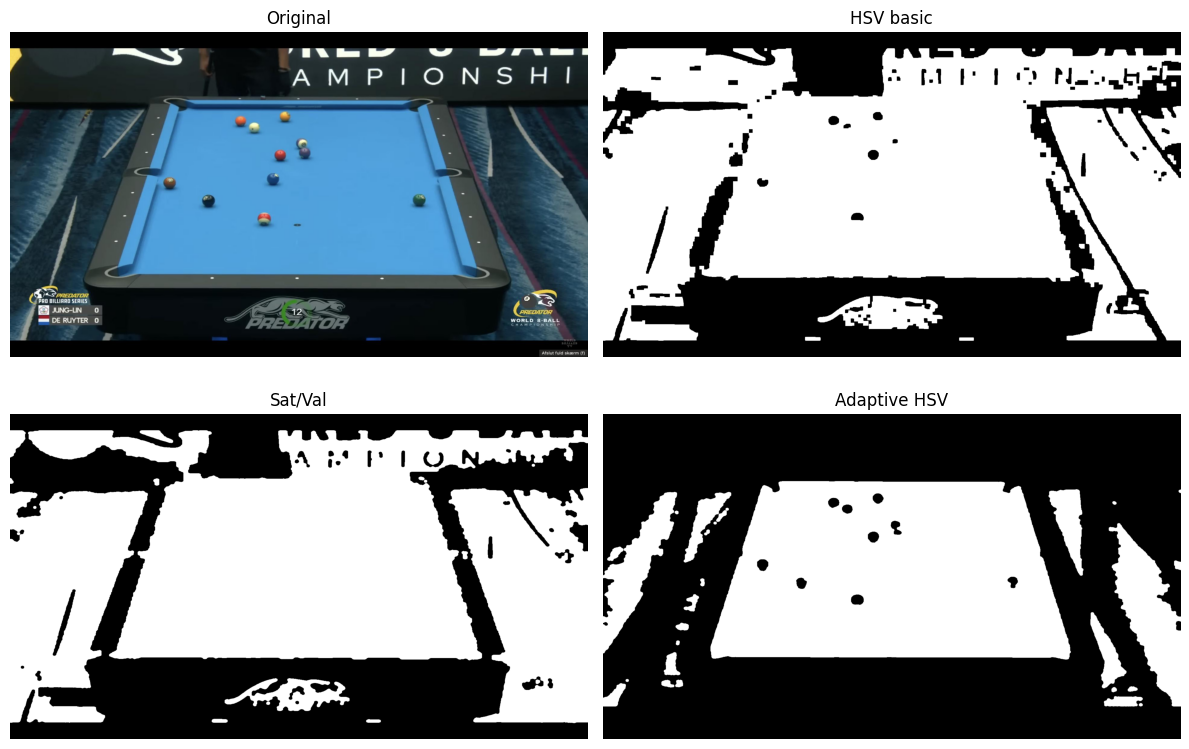

In [9]:
mask_hsv = detect_table_hsv_basic(bgr)
mask_satval = detect_table_satval(bgr)
mask_adaptive = detect_table_mask_adaptive(bgr)

show_many(
    [rgb, mask_hsv, mask_satval, mask_adaptive],
    titles=["Original", "HSV basic", "Sat/Val", "Adaptive HSV"],
    cols=2,
    figsize=(12, 8)
)

### **Contour**

- Mask with noise --> Necessary to extract the main component and remove the noise

In [10]:
def extract_main_table_component(mask):
    ''' 
    Given a mask, extract the largest connected component closest to the image center
    '''
    if mask is None:
        return None

    h, w = mask.shape[:2]
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask)

    if num_labels <= 1:
        return None

    center_pt = np.array([w / 2, h / 2])
    best_label = None
    best_dist = float("inf")

    for i in range(1, num_labels):
        c = centroids[i]
        dist = np.linalg.norm(c - center_pt)
        if dist < best_dist:
            best_dist = dist
            best_label = i

    component_mask = np.uint8(labels == best_label) * 255
    return component_mask

In [11]:
def extract_table_contour(component_mask):
    '''
    Receives a binary mask of the main component and extracts its contour
    '''
    if component_mask is None:
        return None

    contours, _ = cv2.findContours(component_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None

    contour = max(contours, key=cv2.contourArea)
    contour = cv2.convexHull(contour)
    return contour

#### Mask + Contour

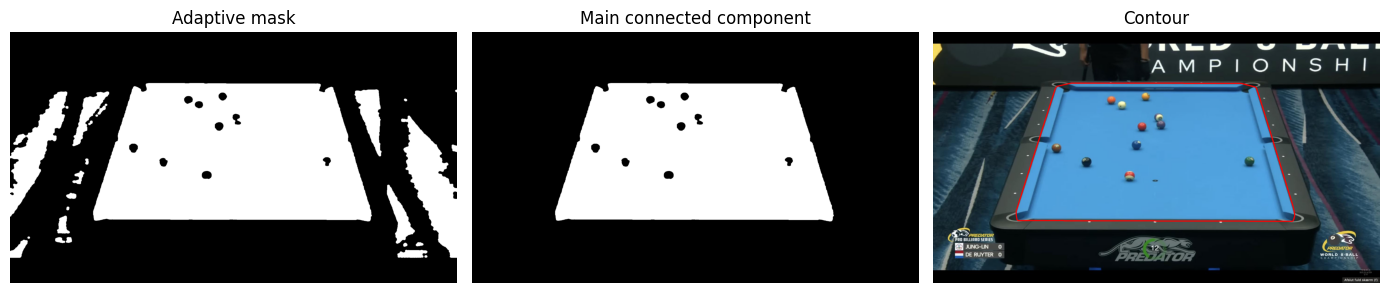

In [12]:
mask = detect_table_mask_adaptive(bgr)
component_mask = extract_main_table_component(mask)
contour = extract_table_contour(component_mask)

rgb_contour = rgb.copy()
if contour is not None:
    cv2.drawContours(rgb_contour, [contour], -1, (255, 0, 0), 3)

show_many(
    [mask, component_mask, rgb_contour],
    titles=["Adaptive mask", "Main connected component", "Contour"],
    cols=3,
    figsize=(14, 5)
)

### **Corners**

In [13]:
def order_points(pts):
    '''
    Orders the argument points in the following order, by summing and differencing the coordinates:
        - Top-left (tl): point with the smallest sum of coordinates (x + y)
        - Bottom-right (br): point with the largest sum of coordinates (x + y)
        - Top-right (tr): point with the smallest difference of coordinates (y - x)
        - Bottom-left (bl): point with the largest difference of coordinates (y - x)
    Returns the ordered points as a numpy array of shape (4, 2) --> [[tl_x, tl_y], [tr_x, tr_y], [br_x, br_y], [bl_x, bl_y]]
    '''
    pts = np.asarray(pts, dtype=np.float32)
    s = pts.sum(axis=1)
    d = np.diff(pts, axis=1)
    tl = pts[np.argmin(s)]
    br = pts[np.argmax(s)]
    tr = pts[np.argmin(d)] 
    bl = pts[np.argmax(d)] 
    return np.array([tl, tr, br, bl], dtype=np.float32)


def polygon_area(pts):
    pts = np.asarray(pts, dtype=np.float32)
    x = pts[:, 0]
    y = pts[:, 1]
    return 0.5 * abs(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1)))

In [14]:
def contour_to_corners_refined(contour):
    if contour is None:
        return None

    peri = cv2.arcLength(contour, True)
    print("Contour perimeter:", peri)

    approx = None
    for eps in [0.01, 0.02, 0.03]:
        approx_candidate = cv2.approxPolyDP(contour, eps * peri, True)
        if len(approx_candidate) == 4:
            approx = approx_candidate
            break

    if approx is not None:
        corners = approx.reshape(4, 2)
    else:
        rect = cv2.minAreaRect(contour)
        corners = cv2.boxPoints(rect)

    corners = order_points(corners)

    if polygon_area(corners) < 1000:
        return None

    return corners

Contour perimeter: 3244.273964881897


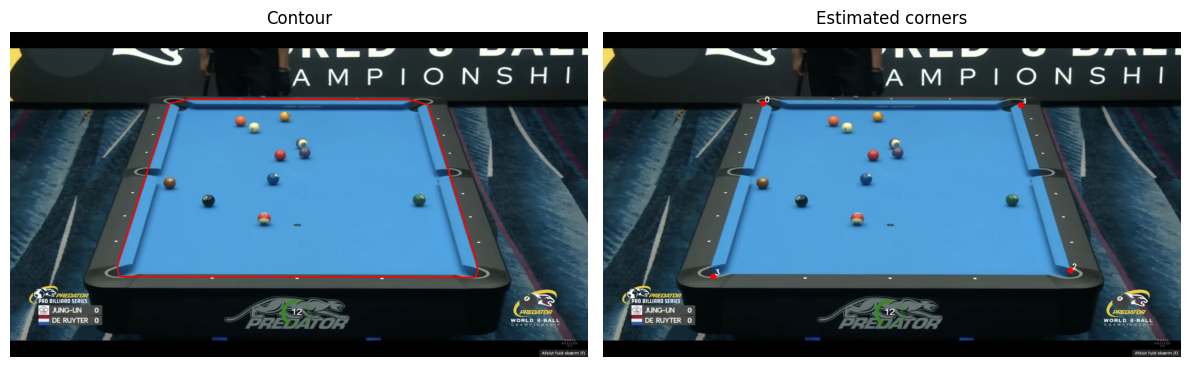

In [15]:
corners = contour_to_corners_refined(contour)
rgb_corners = rgb.copy()
if corners is not None:
    for i, (x, y) in enumerate(corners.astype(int)):
        cv2.circle(rgb_corners, (x, y), 10, (255, 0, 0), -1)
        cv2.putText(rgb_corners, str(i), (x + 5, y - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)

show_many(
    [rgb_contour, rgb_corners],
    titles=["Contour", "Estimated corners"],
    cols=2,
    figsize=(12, 5)
)

### **Warp**

**Goal: Identify table width and height** 

Tried approaches that do not work: 

- identify the smallest size and select its opposite -> why? perspective corrupts distances
- identify the width / height by the order of the corners (tl, tr, br, bl) -> why? we have horizontal and vertical images
- identify all sides lenghts -> why? perspective corrupts distances
- identify through midpoint of every side -> why? perspective corrupts distances 

DON'T KNOW WHAT TO DO